# Лабораторная работа №2
## Кросс-энтропийный метод (CEM)



In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output


In [2]:
env = gym.make('Taxi-v3')
n_states = env.observation_space.n
n_actions = env.action_space.n
print('States:', n_states)
print('Actions:', n_actions)


States: 500
Actions: 6


In [3]:
def initialize_policy(n_states, n_actions):
    return np.ones((n_states, n_actions)) / n_actions

policy = initialize_policy(n_states, n_actions)


In [4]:
def generate_session(env, policy, t_max=10**4):
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):
        a = np.random.choice(n_actions, p=policy[s])
        new_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if done:
            break

    return states, actions, total_reward


In [5]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    reward_threshold = np.percentile(rewards_batch, percentile)
    elite_states = []
    elite_actions = []

    for i in range(len(states_batch)):
        if rewards_batch[i] >= reward_threshold:
            elite_states.extend(states_batch[i])
            elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions


In [6]:
def get_new_policy(elite_states, elite_actions):
    new_policy = np.zeros((n_states, n_actions))

    for s, a in zip(elite_states, elite_actions):
        new_policy[s][a] += 1

    for s in range(n_states):
        if np.sum(new_policy[s]) == 0:
            new_policy[s] = np.ones(n_actions) / n_actions
        else:
            new_policy[s] /= np.sum(new_policy[s])

    return new_policy


In [7]:
def show_progress(rewards_batch, log, percentile):
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)

    log.append([mean_reward, threshold])

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot([x[0] for x in log], label='Mean reward')
    plt.plot([x[1] for x in log], label='Threshold')
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=[-990, 10])
    plt.axvline(threshold, color='r')
    plt.grid()

    clear_output(True)
    print(f'Mean reward = {mean_reward:.3f}, Threshold = {threshold:.3f}')
    plt.show()


Mean reward = -59.576, Threshold = 5.000


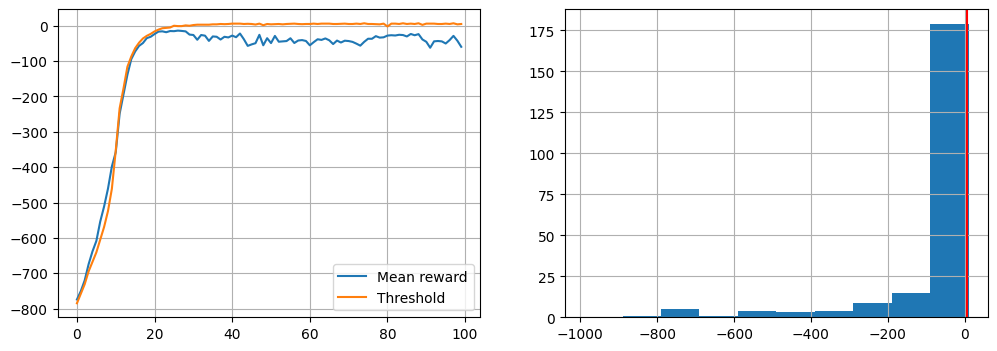

In [8]:
policy = initialize_policy(n_states, n_actions)

n_sessions = 250
percentile = 50
learning_rate = 0.5

log = []

for i in range(100):
    sessions = [generate_session(env, policy) for _ in range(n_sessions)]
    states_batch, actions_batch, rewards_batch = zip(*sessions)

    elite_states, elite_actions = select_elites(
        states_batch, actions_batch, rewards_batch, percentile
    )

    new_policy = get_new_policy(elite_states, elite_actions)

    policy = learning_rate * new_policy + (1 - learning_rate) * policy

    show_progress(rewards_batch, log, percentile)


## Анализ сходимости задачи Taxi-v3 при использовании CEM

В процессе обучения наблюдается характерная динамика:

1. В начале средняя награда находится на уровне менее **-1000**.
2. Затем происходит резкий рост почти до оптимального значения.
3. После этого возможен спад до диапазона **-50 / -100** и колебания.

### Почему в начале награда около -1000?

Начальная политика равномерная (случайная).  
В среде Taxi-v3:

- -1 за каждый шаг,
- -10 за неправильную посадку/высадку,
- +20 за успешную доставку.

Случайные действия приводят к множеству штрафов и превышению лимита шагов, поэтому суммарная награда сильно отрицательная.



### Почему происходит быстрый рост?

Taxi-v3 — дискретная и относительно небольшая среда:

- 500 состояний,
- 6 действий,
- информативная система наград.

Кросс-энтропийный метод усиливает действия из лучших эпизодов.  
Даже небольшие улучшения (например, меньше штрафов -10) резко повышают суммарную награду.  
Из-за компактности среды хорошие стратегии быстро закрепляются.


### Почему затем награда снижается?

Это связано с особенностями CEM:

- обучение только на элитных эпизодах,
- стохастичность генерации сессий,
- возможное переобучение на случайные траектории,
- уменьшение разнообразия действий,
- сглаживание через learning_rate.

После достижения хорошего решения возможны колебания и небольшая деградация политики.


### Вывод

Быстрая сходимость объясняется дискретностью среды и информативными наградами.  
Последующее снижение связано со стохастической природой метода и обучением только на лучших эпизодах.